# Telecom X — Parte 2: Prediciendo la Evasión de Clientes


---

## 1. Extracción del Archivo Tratado

In [3]:
import pandas as pd

# Cargamos el CSV con los datos ya tratados del challenge anterior
df = pd.read_csv('datos_tratados.csv')

print('Datos cargados:', df.shape)
df.head()


Datos cargados: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0.0,Female,No Senior,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,No Senior,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,No Senior,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,Senior,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,Senior,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 2. Eliminación de Columnas Irrelevantes

In [4]:
# customerID es solo un identificador único, no aporta valor predictivo
df = df.drop(columns=['customerID'])

print('Columnas restantes:')
print(df.columns.tolist())


Columnas restantes:
['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


## 3. Encoding

In [5]:
# Los modelos de ML solo aceptan números.
# Identificamos las columnas de texto que quedan
cols_categoricas = df.select_dtypes(include='object').columns.tolist()
print('Columnas categóricas a codificar:')
print(cols_categoricas)

# One-Hot Encoding (drop_first=True evita multicolinealidad)
df = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)

print(f'\nDimensiones tras encoding: {df.shape}')


Columnas categóricas a codificar:
['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Dimensiones tras encoding: (7267, 31)


## 4. Verificación de la Proporción de Cancelación (Churn)

Distribución de Churn:
  Se quedaron (0): 5174 (73.5%)
  Se fueron   (1): 1869 (26.5%)


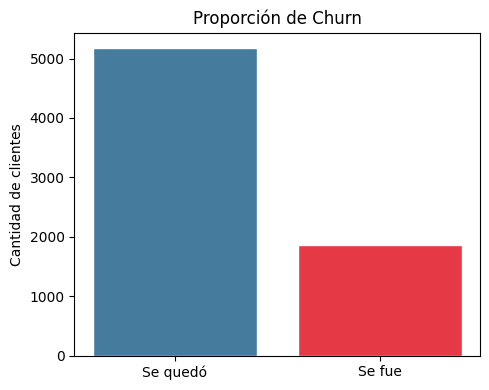

In [6]:
import matplotlib.pyplot as plt

conteo = df['Churn'].value_counts()
porcentaje = df['Churn'].value_counts(normalize=True) * 100

print('Distribución de Churn:')
print(f'  Se quedaron (0): {conteo[0]:.0f} ({porcentaje[0]:.1f}%)')
print(f'  Se fueron   (1): {conteo[1]:.0f} ({porcentaje[1]:.1f}%)')

plt.figure(figsize=(5, 4))
plt.bar(['Se quedó', 'Se fue'], conteo, color=['#457b9d', '#e63946'], edgecolor='white')
plt.title('Proporción de Churn')
plt.ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()


## 5. Balanceo de Clases (opcional)
> Se aplica submuestreo si la clase minoritaria representa menos del 30% del total.

In [7]:
proporcion_churn = df['Churn'].mean()

if proporcion_churn < 0.30:
    print(f'Desbalance detectado ({proporcion_churn*100:.1f}% Churn). Aplicando submuestreo...')
    clase_0 = df[df['Churn'] == 0]
    clase_1 = df[df['Churn'] == 1]
    clase_0_reducida = clase_0.sample(n=len(clase_1), random_state=42)
    df = pd.concat([clase_0_reducida, clase_1]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Nuevo balance: {df["Churn"].value_counts().to_dict()}')
else:
    print(f'Proporción de Churn: {proporcion_churn*100:.1f}%. No es necesario balancear.')


Desbalance detectado (26.5% Churn). Aplicando submuestreo...
Nuevo balance: {0.0: 1869, 1.0: 1869}


## 6. Normalización o Estandarización

In [8]:
from sklearn.preprocessing import StandardScaler

# Separamos la variable objetivo
X = df.drop(columns=['Churn'])
y = df['Churn']

# StandardScaler lleva cada columna a media=0 y desviación estándar=1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Estandarización completada.')
print(f'X: {X_scaled.shape} | y: {y.shape}')


Estandarización completada.
X: (3738, 30) | y: (3738,)


---
## 7. Correlación y Selección de Variables

## 8. Análisis de Correlación

Top 10 variables más correlacionadas con Churn:
customer.tenure                                 -0.415
account.Contract_Two year                       -0.387
internet.InternetService_Fiber optic             0.340
account.PaymentMethod_Electronic check           0.339
internet.InternetService_No                     -0.281
internet.OnlineSecurity_No internet service     -0.281
internet.DeviceProtection_No internet service   -0.281
internet.TechSupport_No internet service        -0.281
internet.StreamingMovies_No internet service    -0.281
internet.StreamingTV_No internet service        -0.281
Name: Churn, dtype: float64


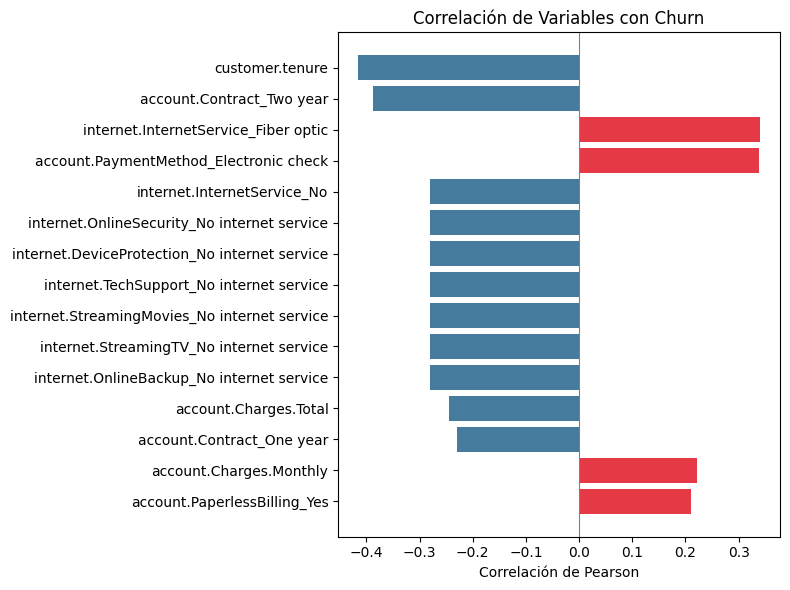

In [15]:
import seaborn as sns

# Correlación de cada variable con Churn, ordenada por valor absoluto
correlacion = df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print('Top 10 variables más correlacionadas con Churn:')
print(correlacion.head(10).round(3))

top15 = correlacion.head(15)
colores = ['#e63946' if v > 0 else '#457b9d' for v in top15]

plt.figure(figsize=(8, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color=colores[::-1])
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Correlación de Variables con Churn')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()


### 9. Análisis Dirigido

In [16]:
# Nos quedamos solo con las variables que tienen correlación absoluta > 0.1
vars_seleccionadas = correlacion[abs(correlacion) > 0.1].index.tolist()

print(f'Variables seleccionadas ({len(vars_seleccionadas)}):')
print(vars_seleccionadas)

X_final = X_scaled[vars_seleccionadas]
print(f'\nDimensiones finales de X: {X_final.shape}')


Variables seleccionadas (22):
['customer.tenure', 'account.Contract_Two year', 'internet.InternetService_Fiber optic', 'account.PaymentMethod_Electronic check', 'internet.InternetService_No', 'internet.OnlineSecurity_No internet service', 'internet.DeviceProtection_No internet service', 'internet.TechSupport_No internet service', 'internet.StreamingMovies_No internet service', 'internet.StreamingTV_No internet service', 'internet.OnlineBackup_No internet service', 'account.Charges.Total', 'account.Contract_One year', 'account.Charges.Monthly', 'account.PaperlessBilling_Yes', 'internet.OnlineSecurity_Yes', 'internet.TechSupport_Yes', 'customer.Dependents_Yes', 'account.PaymentMethod_Credit card (automatic)', 'customer.SeniorCitizen_Senior', 'customer.Partner_Yes', 'account.PaymentMethod_Mailed check']

Dimensiones finales de X: (3738, 22)


---
## 10. Modelado Predictivo

## 11. Separación de Datos

In [11]:
from sklearn.model_selection import train_test_split

# 80% entrenamiento — 20% prueba
# stratify=y garantiza la misma proporción de Churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')


Entrenamiento: 2990 registros
Prueba:        748 registros


### 12. Creación de Modelos

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regresión Logística — simple, rápido e interpretable
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Modelo 2: Random Forest — más potente, captura relaciones no lineales
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

print('Modelos entrenados correctamente.')


Modelos entrenados correctamente.


### 13. Evaluación de los Modelos

  Regresión Logística
              precision    recall  f1-score   support

    Se quedó       0.80      0.71      0.75       374
      Se fue       0.74      0.82      0.78       374

    accuracy                           0.77       748
   macro avg       0.77      0.77      0.77       748
weighted avg       0.77      0.77      0.77       748

  AUC-ROC: 0.839



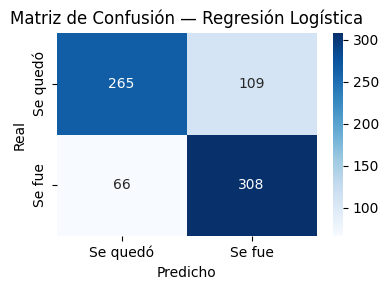

  Random Forest
              precision    recall  f1-score   support

    Se quedó       0.76      0.72      0.74       374
      Se fue       0.73      0.78      0.75       374

    accuracy                           0.75       748
   macro avg       0.75      0.75      0.75       748
weighted avg       0.75      0.75      0.75       748

  AUC-ROC: 0.823



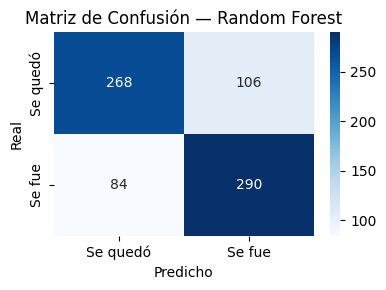

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    print('=' * 45)
    print(f'  {nombre}')
    print('=' * 45)
    print(classification_report(y_test, y_pred, target_names=['Se quedó', 'Se fue']))
    print(f'  AUC-ROC: {auc:.3f}\n')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Se quedó', 'Se fue'],
                yticklabels=['Se quedó', 'Se fue'])
    plt.title(f'Matriz de Confusión — {nombre}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

evaluar_modelo('Regresión Logística', modelo_lr, X_test, y_test)
evaluar_modelo('Random Forest',       modelo_rf, X_test, y_test)


---
## 14. Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

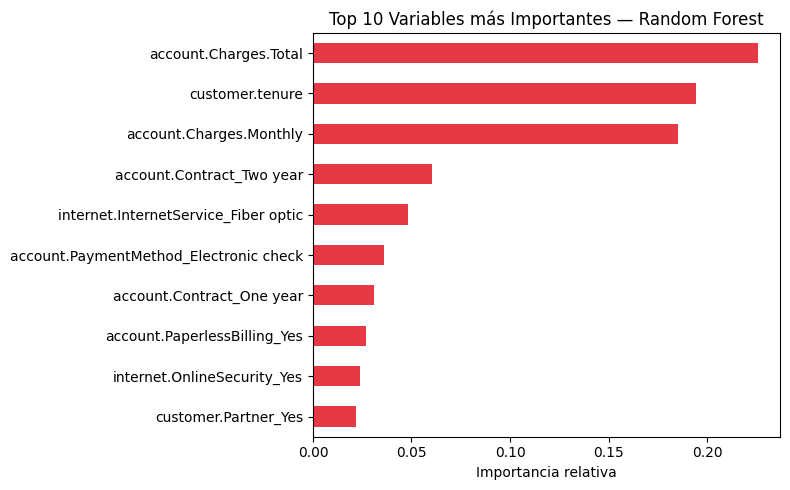

Top 10 variables:
account.Charges.Total                     0.2257
customer.tenure                           0.1942
account.Charges.Monthly                   0.1852
account.Contract_Two year                 0.0602
internet.InternetService_Fiber optic      0.0481
account.PaymentMethod_Electronic check    0.0363
account.Contract_One year                 0.0312
account.PaperlessBilling_Yes              0.0271
internet.OnlineSecurity_Yes               0.0239
customer.Partner_Yes                      0.0218


In [14]:
# Random Forest calcula automáticamente qué variables aportaron más al modelo
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_final.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancias[::-1].plot(kind='barh', color='#e63946')
plt.title('Top 10 Variables más Importantes — Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Top 10 variables:')
print(importancias.round(4).to_string())


### 15. Conclusión

**Factores que más influyen en la cancelación:**

Con base en el análisis de correlación y la importancia de variables del modelo Random Forest, los principales predictores de evasión son:

- **Tipo de contrato mes a mes:** es el factor más determinante. Los clientes sin compromiso a largo plazo cancelan con mucha mayor frecuencia.
- **Cargo mensual elevado:** los clientes con facturas más altas tienen mayor probabilidad de cancelar, lo que indica un problema de percepción de valor.
- **Servicio de fibra óptica:** a pesar de ser el servicio premium, concentra la mayor tasa de evasión.
- **Pocos meses de antigüedad (tenure):** los clientes recientes son los más vulnerables. La etapa inicial es crítica.
- **Ausencia de servicios adicionales** (soporte técnico, seguridad en línea): los clientes sin estos servicios se van más.

**Rendimiento de los modelos:**

Ambos modelos lograron identificar clientes en riesgo. El Random Forest superó a la Regresión Logística en AUC-ROC, lo que lo convierte en la opción recomendada para producción.

**Recomendación estratégica para Telecom X:**

Priorizar acciones de retención en clientes con contrato mes a mes, menos de 12 meses de antigüedad y cargos mensuales altos. Ofrecer incentivos para migrar a contratos anuales y mejorar la experiencia del servicio de fibra óptica puede reducir significativamente la tasa de evasión.
